# Universidad de Buenos Aires - FIUBA - LSE
# Aprendizaje Profundo - TP1
# Cohorte 26 - 4to bimestre 2026

## **Alumno 1:** Denis Zhbankov

## **Alumno 2:** Elian Pinzas

# **PREGUNTA 1** (Temas de la clase 1 y 2)

## **Comparación de Gradiente Descendente y Adam en una Función de Costo No Convexa**

En este ejercicio se compararán los optimizadores Gradiente Descendente (GD) y Adam en la minimización de una función de costo basada en una red neuronal de una sola conexión sináptica:
$$
z = w x + b
$$
Con función de activación tangente hiperbólica:

$$
\hat{y} = a(z) = \tanh(z) = \tanh(w x + b)
$$

<br>

Se analizará la trayectoria de aprendizaje de ambos algoritmos y se evaluará su eficiencia con diferentes tasas de aprendizaje (learning rate).

<br>

La función de costo utilizada es el Error Cuadrático Medio (MSE):

$$
J(w, b) = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}_i - y_i)^2
$$

$$
J(w, b) = \frac{1}{m} \sum_{i=1}^{m} ( \tanh(w x_i + b) - y_i )^2
$$

donde \\( w \\) y \\( b \\) son los parámetros que se busca optimizar.

<br>

Si bien es cierto, en estos experimentos buscamos tan solo comparar optimizadores (GD vs Adam), de igual forma se necesitará una especie de dataset. Este será sintético y solo de prueba, por ende tendrán cierta libertad para elegir sus valores. Sin embargo deberán tomar en cuenta que cumpla la siguiente estructura:

`x = np.linspace(ini, fin, n)`

donde `x` es un array de una sola dimensión y con `n` cantidad de valores ($n>=200$). Y tiene un rango de valores desde `ini` hasta `fin`. Recomiendo que sea simétrico, es decir, los mismos valores solo que con el signo cambiado, por ejemplo `ini=-3, fin=3`, `ini=-5, fin=5`, `ini=-1, fin=1`, etc. Queda a elección de ustedes.

<br>

Y con un target `y`:

`y = funcion_no_lineal(x) + ruido`

donde `y` es también un vector de una sola dimensión de tamaño `n` que sigue un patrón no lineal (elegido por ustedes) con respecto a `x` adicionando un ruido que puede ser creado con algunas de las funciones del paquete `np.random`.

El patrón no lineal puede ser una función trigonométrica, exponencial, logarítmica, sigmoidal, polinómica de grado mayor o igual a 3, o la combinación de varias de estas (recomendado), acotada de -1 a 1 en el eje vertical. Pero sean prudentes en la elección de la función no lineal, ya que recuerden que es una red de una sola conexión, por ende tampoco elijan algo tan complejo que al final provoque que el modelo no pueda converger. Pero tampoco vale usar una `tanh` sola, usen otra función, o si la van a usar debe estar combinada con otros patrones no lineales. Ya que al ser la función de activación tambien una `tanh`, el modelo la tendrá muy fácil converger a ella.

### 1a) Implementación del Gradiente Descendente (1 punto)
- Implementar el algoritmo del Gradiente Descendente (GD) para minimizar \\( J(w, b) \\).
- Utilizar 100 épocas y 3 diferentes learning rates `(0.1, 0.01, 0.001)`.
- Inicializar valores de \\( w \\) y \\( b \\) de manera aleatoria con `np.random.randn()`.
- Graficar la función de Costo \\( J(w, b) \\) VS número de época para comparar cómo converge la función para cada uno de los 3 learning rates. Las 3 gráficas deben estar en el mismo plot y superpuestas para que la comparación visual sea más fácil. Deben graficarlas con diferente color y con leyenda para no confundirlas.

<br>

El optimizador del Gradiente Descendente se debe implementar haciendo el código desde cero y paso a paso. Se pueden usar librerías como `numpy`, `scipy`, `matplotlib` o similares. Pero no está permitido usar PyTorch ni TensorFlow o frameworks que ya contengan el optimizador desarrollado.

In [73]:
import numpy as np
import matplotlib.pyplot as plt

Generación de dataset sintético

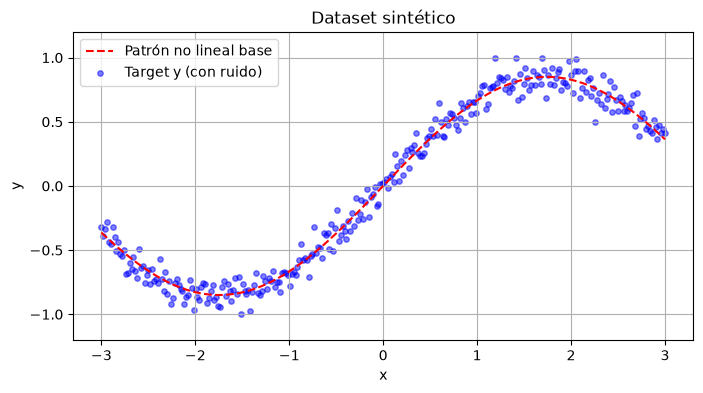

In [74]:
n = 300
ini, fin = -3, 3
x = np.linspace(ini, fin, n)

# Función no lineal para 'y' (sin(x))
y_limpio = 0.85 * np.sin(0.9 * x)

np.random.seed(42)
ruido = np.random.normal(loc=0.0, scale=0.08, size=n)

# Target final y
y = y_limpio + ruido

# Se asegura que el dataset no se vaya de rango (por el ruido)
y = np.clip(y, -1.0, 1.0)

# Visualización
plt.figure(figsize=(8, 4))
plt.plot(x, y_limpio, color='red', linestyle='--', label='Patrón no lineal base')
plt.scatter(x, y, color='blue', alpha=0.5, s=15, label='Target y (con ruido)')
plt.title("Dataset sintético")
plt.xlabel("x")
plt.ylabel("y")
plt.ylim(-1.2, 1.2)
plt.legend()
plt.grid(True)
plt.show()

1a) Implementación de gradiente descendiente

Valores iniciales aleatorios -> w_0: -1.0856, b_0: 0.9973

LR   0.1 -> Costo Final: 0.044443 | w_final: 0.6319, b_final: 0.0056
LR  0.01 -> Costo Final: 1.235994 | w_final: -0.2665, b_final: 1.1713
LR 0.001 -> Costo Final: 1.958198 | w_final: -1.0127, b_final: 1.0277


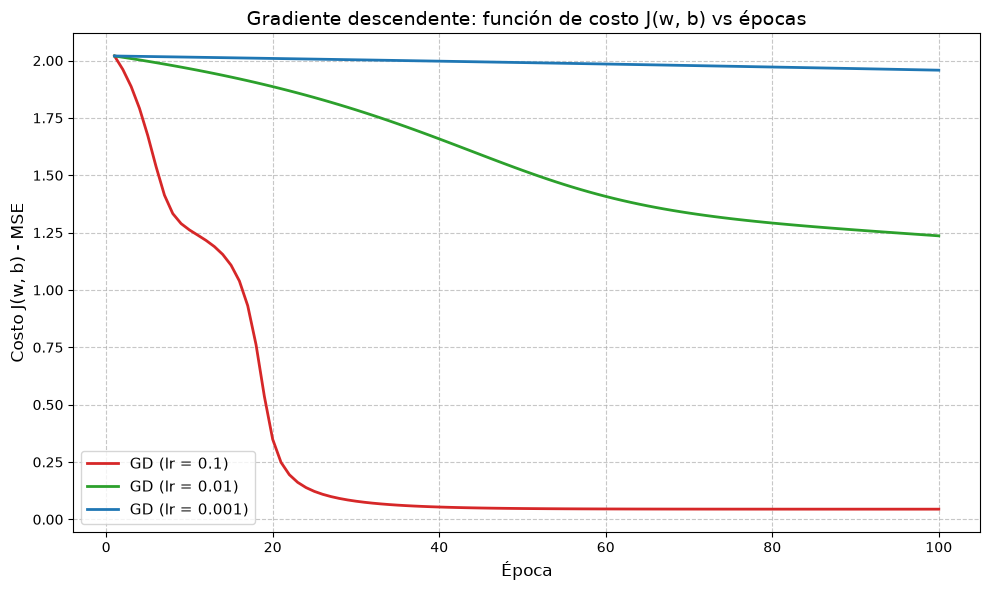

In [75]:
def forward_pass(x, w, b):
    z = w * x + b
    y_hat = np.tanh(z)
    return y_hat

def calcular_costo(y_hat, y):
    m = len(y)
    return (1 / m) * np.sum((y_hat - y) ** 2)

def calcular_gradientes(x, y, y_hat):
    m = len(y)
    # Regla de la cadena: dJ/dy_hat * dy_hat/dz
    error = y_hat - y
    dtanh = 1 - y_hat ** 2
    dz = (2 / m) * error * dtanh

    dw = np.sum(dz * x)
    db = np.sum(dz)
    return dw, db

# Implementación de algoritmo de GD
def entrenar_gd(x, y, lr, epochs, w_inicial, b_inicial):
    w = w_inicial
    b = b_inicial
    historial_costo = []

    for epoch in range(epochs):
        y_hat = forward_pass(x, w, b)

        costo = calcular_costo(y_hat, y)
        historial_costo.append(costo)

        dw, db = calcular_gradientes(x, y, y_hat)

        # Actualización de parámetros
        w = w - lr * dw
        b = b - lr * db

    return historial_costo, w, b

# Se utilizan 100 épocas y 3 learning rates: 0.1, 0.01, 0.001
epochs = 100
learning_rates = [0.1, 0.01, 0.001]
colores = ['#d62728', '#2ca02c', '#1f77b4']  # Rojo, Verde, Azul

# Semilla para los 3 learning rates
np.random.seed(123)
w_init = np.random.randn()
b_init = np.random.randn()

print(f"Valores iniciales aleatorios -> w_0: {w_init:.4f}, b_0: {b_init:.4f}\n")

# Graficar J(w,b) vs épocas
plt.figure(figsize=(10, 6))

for lr, color in zip(learning_rates, colores):
    hist_costo, w_final, b_final = entrenar_gd(
        x, y, lr=lr, epochs=epochs, w_inicial=w_init, b_inicial=b_init
    )

    plt.plot(
        range(1, epochs + 1),
        hist_costo,
        label=f'GD (lr = {lr})',
        color=color,
        linewidth=2
    )
    print(f"LR {lr:5} -> Costo Final: {hist_costo[-1]:.6f} | w_final: {w_final:.4f}, b_final: {b_final:.4f}")

plt.title("Gradiente descendente: función de costo J(w, b) vs épocas", fontsize=14)
plt.xlabel("Época", fontsize=12)
plt.ylabel("Costo J(w, b) - MSE", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

### 1b) Implementación de Adam (2 punto)  
- Implementar el algoritmo de Adam para minimizar \\( J(w, b) \\).  
- Utilizar 100 épocas y 3 diferentes learning rates `(0.1, 0.01, 0.001)`.
- Utilizar los mismos valores de \\( w \\) y \\( b \\) que se usaron para GD **(IMPORTANTE)**.
- Hacer 2 modelos, uno full-batch y otro con mini-batch.
- El batch size es a elección de ustedes, pero debe ser mayor o igual a 16.
- Graficar la función de Costo \\( J(w, b) \\) VS número de época para comparar cómo converge la función para ambos modelos y para los 3 learning rates. Deben haber 2 plots separados o 2 subplots, uno para las 3 gráficas de Adam full-batch y otro para las 3 gráficas de Adam mini-batch.

<br>

Al igual que para GD, ambas versiones del optimizador Adam también se deben implementar desde cero y paso a paso. Se pueden usar librerías como `numpy`, `scipy`, `matplotlib` o similares. Pero no está permitido usar PyTorch ni TensorFlow o frameworks que ya contengan el optimizador desarrollado.

Valores iniciales (iguales a GD) -> w_0: -1.0856, b_0: 0.9973

=== ADAM FULL-BATCH ===
LR 0.1   -> Costo Final: 0.077817 | w_final: 1.4386, b_final: 0.0392
LR 0.01  -> Costo Final: 1.309611 | w_final: -0.3314, b_final: 1.4958
LR 0.001 -> Costo Final: 1.909053 | w_final: -0.9822, b_final: 1.1000

=== ADAM MINI-BATCH ===
LR 0.1   -> Costo Final: 0.044530 | w_final: 0.6138, b_final: 0.0208
LR 0.01  -> Costo Final: 0.044411 | w_final: 0.6213, b_final: 0.0041
LR 0.001 -> Costo Final: 1.296179 | w_final: -0.3359, b_final: 1.3912


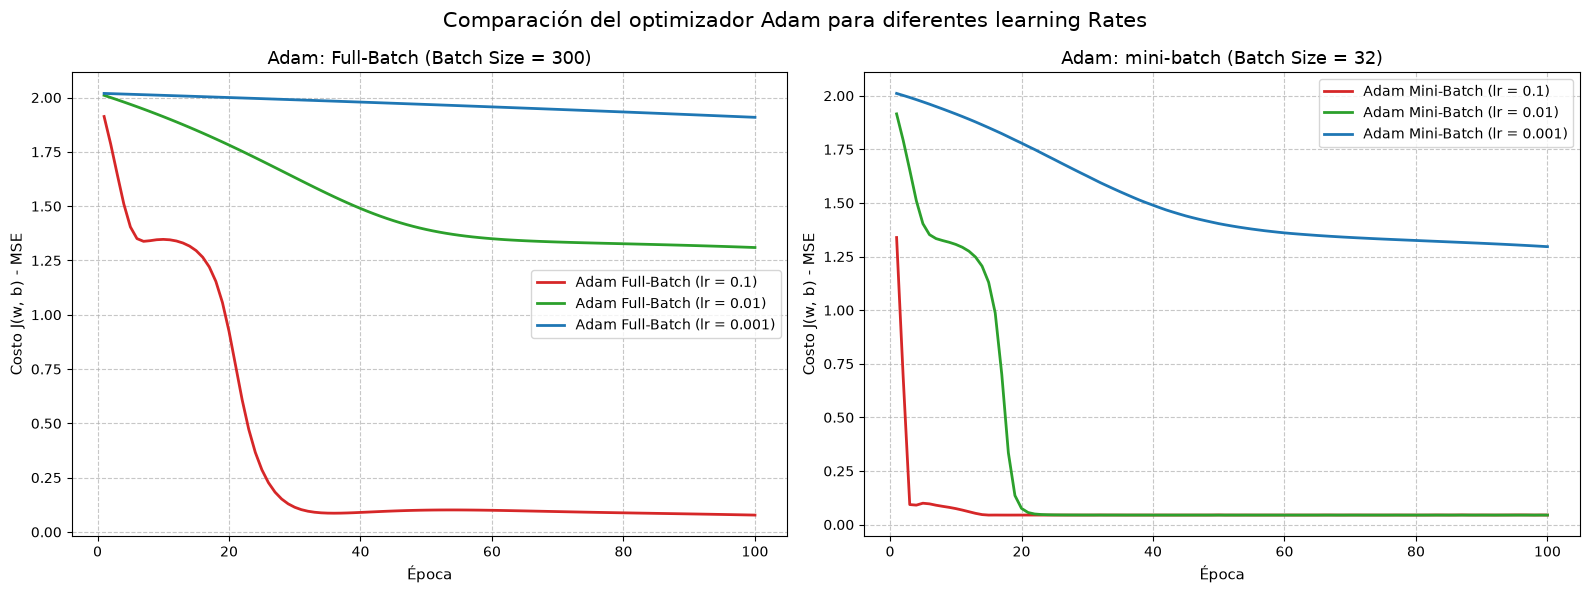

In [76]:
print(f"Valores iniciales (iguales a GD) -> w_0: {w_init:.4f}, b_0: {b_init:.4f}\n")

def entrenar_adam(x, y, lr, epochs, w_inicial, b_inicial, batch_size=None, beta1=0.9, beta2=0.999, eps=1e-8):
    w, b = w_inicial, b_inicial

    # Inicialización de momentos
    mw, mb = 0.0, 0.0
    vw, vb = 0.0, 0.0

    historial_costo = []
    t = 0
    m_samples = len(x)

    # Si batch_size es None o igual al total de muestras, es Full-Batch
    if batch_size is None or batch_size >= m_samples:
        batch_size = m_samples

    for epoch in range(epochs):
        # Para mini-batch, se mezclan los datos al inicio de cada época
        indices = np.arange(m_samples)
        np.random.shuffle(indices)
        x_shuffled = x[indices]
        y_shuffled = y[indices]

        # Iteración sobre mini-batches
        for i in range(0, m_samples, batch_size):
            x_b = x_shuffled[i:i + batch_size]
            y_b = y_shuffled[i:i + batch_size]

            t += 1

            y_hat_b = forward_pass(x_b, w, b)
            dw, db = calcular_gradientes(x_b, y_b, y_hat_b)

            # Acumular primer momento
            mw = beta1 * mw + (1 - beta1) * dw
            mb = beta1 * mb + (1 - beta1) * db

            # Acumular segundo momento
            vw = beta2 * vw + (1 - beta2) * (dw ** 2)
            vb = beta2 * vb + (1 - beta2) * (db ** 2)

            # Corrección de sesgo
            mw_hat = mw / (1 - beta1 ** t)
            mb_hat = mb / (1 - beta1 ** t)
            vw_hat = vw / (1 - beta2 ** t)
            vb_hat = vb / (1 - beta2 ** t)

            # Actualización de parámetros
            w -= lr * mw_hat / (np.sqrt(vw_hat) + eps)
            b -= lr * mb_hat / (np.sqrt(vb_hat) + eps)

        # Costo
        y_hat_full = forward_pass(x, w, b)
        costo_poca = calcular_costo(y_hat_full, y)
        historial_costo.append(costo_poca)

    return historial_costo, w, b

# Batch size mayor a 16
batch_size_elegido = 32

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

print("=== ADAM FULL-BATCH ===")
for lr, color in zip(learning_rates, colores):
    hist, w_f, b_f = entrenar_adam(
        x, y, lr=lr, epochs=epochs, w_inicial=w_init, b_inicial=b_init, batch_size=len(x)
    )
    ax1.plot(range(1, epochs + 1), hist, label=f'Adam Full-Batch (lr = {lr})', color=color, linewidth=2)
    print(f"LR {lr:<5} -> Costo Final: {hist[-1]:.6f} | w_final: {w_f:.4f}, b_final: {b_f:.4f}")

ax1.set_title("Adam: Full-Batch (Batch Size = 300)", fontsize=13)
ax1.set_xlabel("Época", fontsize=11)
ax1.set_ylabel("Costo J(w, b) - MSE", fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend(fontsize=10)

print("\n=== ADAM MINI-BATCH ===")
for lr, color in zip(learning_rates, colores):
    hist, w_f, b_f = entrenar_adam(
        x, y, lr=lr, epochs=epochs, w_inicial=w_init, b_inicial=b_init, batch_size=batch_size_elegido
    )
    ax2.plot(range(1, epochs + 1), hist, label=f'Adam Mini-Batch (lr = {lr})', color=color, linewidth=2)
    print(f"LR {lr:<5} -> Costo Final: {hist[-1]:.6f} | w_final: {w_f:.4f}, b_final: {b_f:.4f}")

ax2.set_title(f"Adam: mini-batch (Batch Size = {batch_size_elegido})", fontsize=13)
ax2.set_xlabel("Época", fontsize=11)
ax2.set_ylabel("Costo J(w, b) - MSE", fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend(fontsize=10)

plt.suptitle("Comparación del optimizador Adam para diferentes learning Rates", fontsize=15, y=0.98)
plt.tight_layout()
plt.show()

### 1c) Comparativa de optimizadores (0.5 puntos)  
- Comparar el resultado y rendimiento de GD VS Adam (full-batch) VS Adam (mini-batch) para cada uno de los learning rates por separado. Hacerlo con gráficas y tablas. Deben haber 3 plots o 3 subplots, uno para cada learning rate. Y las leyendas deben diferenciar al optimizador por color.
- Graficar el dataset original sintético (y(x)) y compararlo con la función hallada por el modelo, para ver si efectivamente el modelo logró deducir un patrón no lineal parecido al patrón no lineal escogido para el dataset. Hacerlo para cada optimizador y cada learning rate en un plot grande de 9 subplots.
- Redactar conclusiones analíticas que resalten las diferencias entre cada optimizador. No solo deben comparar el resultado final del costo, sino también la velocidad de convergencia y otros aspectos que consideren relevantes. Le voy a tomar mucha importancia a este último punto, así que su análisis debe ser claro, detallado y con criterio acorde a los resultados obtenidos.

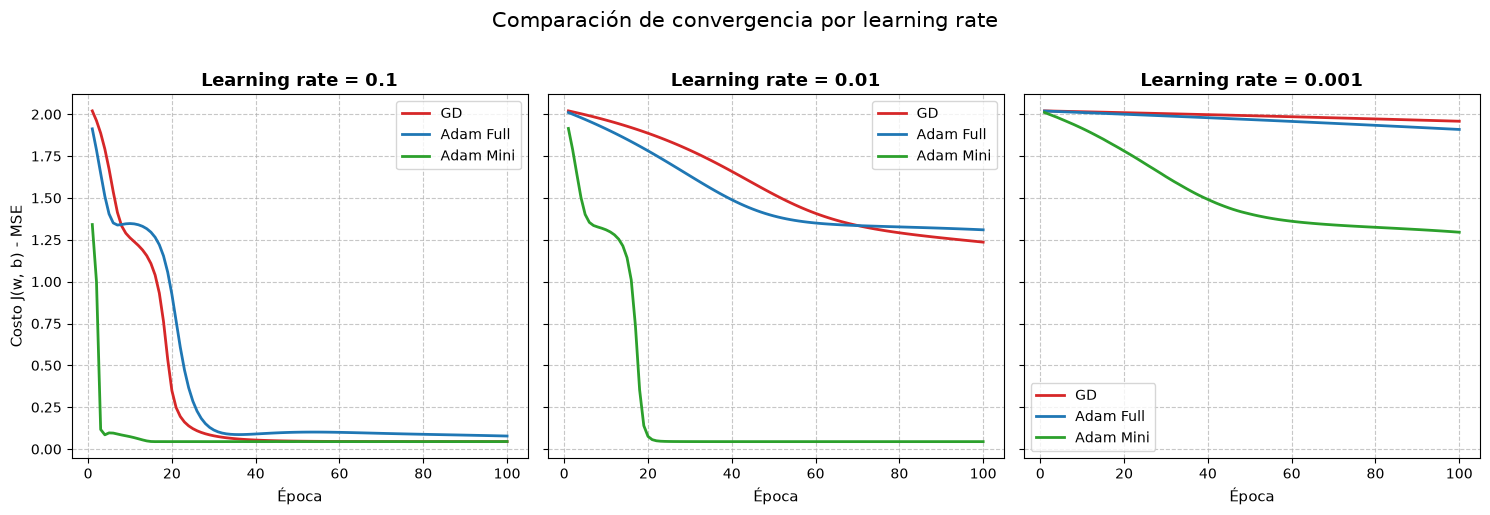

In [77]:
colores_opt = {
    'GD': '#d62728',          # Rojo
    'Adam Full': '#1f77b4',   # Azul
    'Adam Mini': '#2ca02c'    # Verde
}

# Ejecución y almacenamiento de historias y parámetros finales
resultados = {} # Estructura: resultados[lr][optimizador] = (historial_costo, w_final, b_final)

for lr in learning_rates:
    resultados[lr] = {}

    # 1. GD
    hist_gd, w_gd, b_gd = entrenar_gd(x, y, lr=lr, epochs=epochs, w_inicial=w_init, b_inicial=b_init)
    resultados[lr]['GD'] = (hist_gd, w_gd, b_gd)

    # 2. Adam Full-Batch
    hist_af, w_af, b_af = entrenar_adam(x, y, lr=lr, epochs=epochs, w_inicial=w_init, b_inicial=b_init, batch_size=len(x))
    resultados[lr]['Adam Full'] = (hist_af, w_af, b_af)

    # 3. Adam Mini-Batch
    hist_am, w_am, b_am = entrenar_adam(x, y, lr=lr, epochs=epochs, w_inicial=w_init, b_inicial=b_init, batch_size=batch_size_elegido)
    resultados[lr]['Adam Mini'] = (hist_am, w_am, b_am)

# 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for idx, lr in enumerate(learning_rates):
    ax = axes[idx]

    for opt_name, (hist, _, _) in resultados[lr].items():
        ax.plot(range(1, epochs + 1), hist, label=opt_name, color=colores_opt[opt_name], linewidth=2)

    ax.set_title(f"Learning rate = {lr}", fontsize=13, fontweight='bold')
    ax.set_xlabel("Época", fontsize=11)
    if idx == 0:
        ax.set_ylabel("Costo J(w, b) - MSE", fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(fontsize=10)

plt.suptitle("Comparación de convergencia por learning rate", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

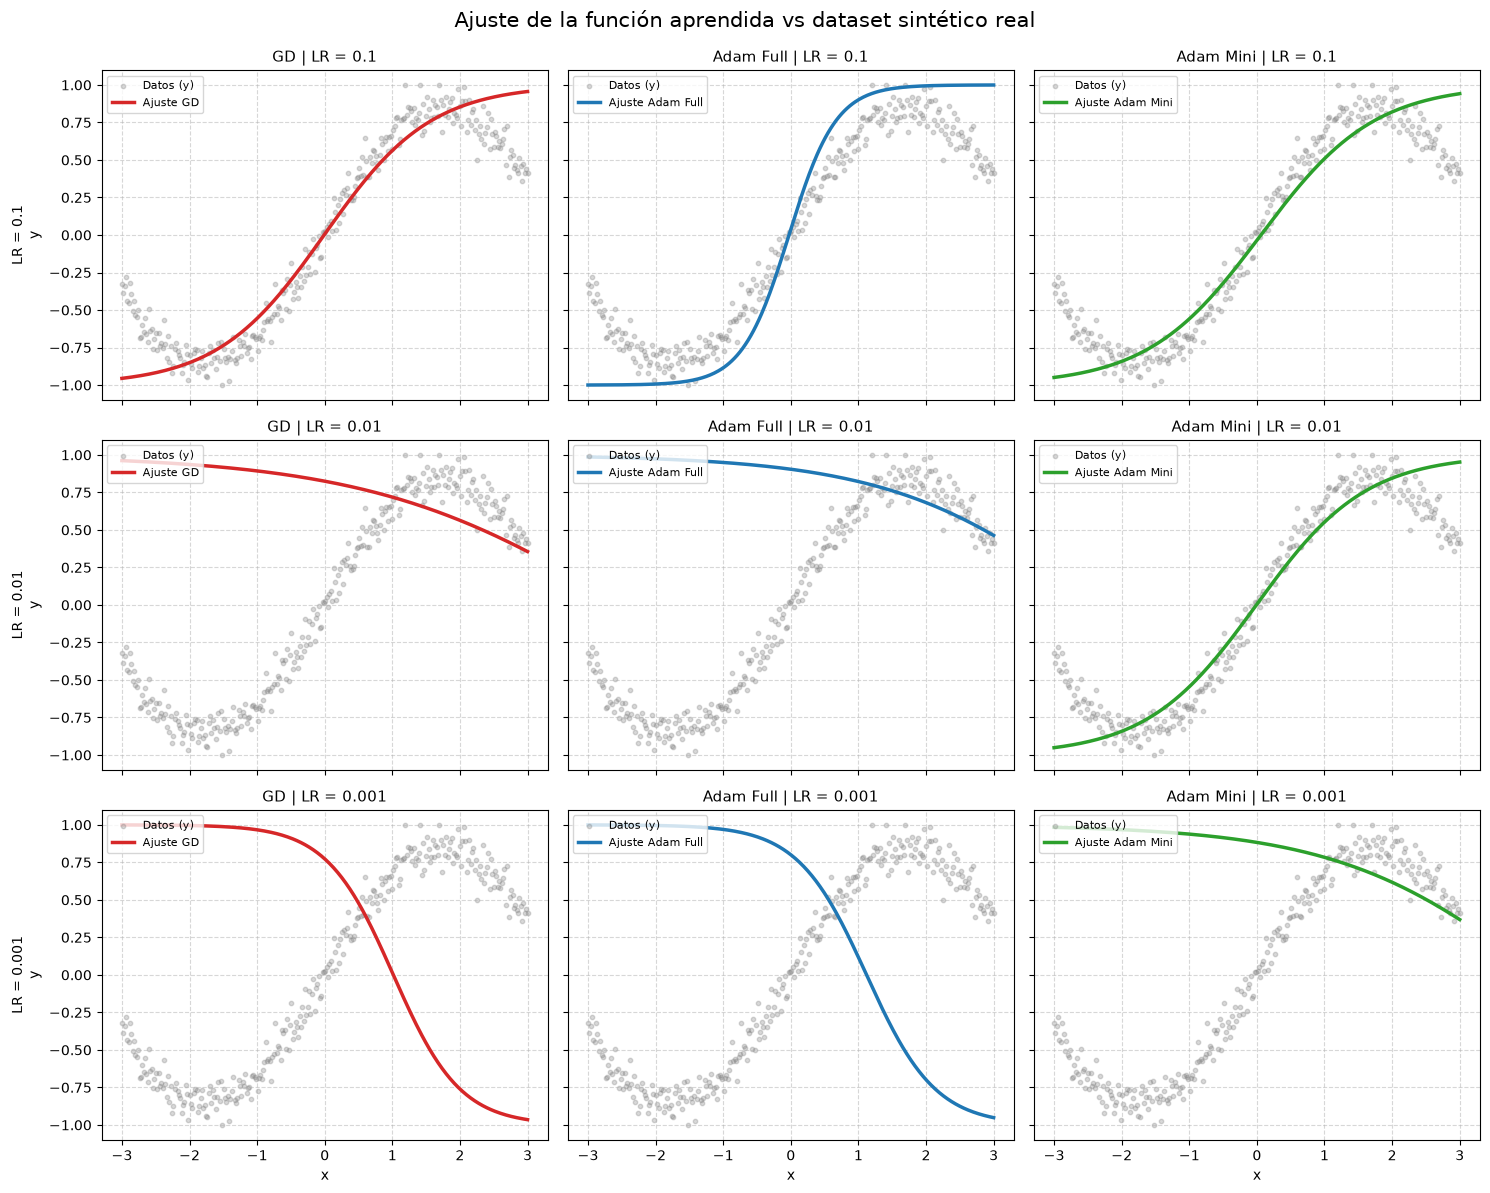

In [78]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharex=True, sharey=True)

opt_keys = ['GD', 'Adam Full', 'Adam Mini']

for i, lr in enumerate(learning_rates):
    for j, opt_name in enumerate(opt_keys):
        ax = axes[i, j]
        _, w_f, b_f = resultados[lr][opt_name]

        # Predicción del modelo ajustado
        y_pred = forward_pass(x, w_f, b_f)

        # Dataset original vs Ajuste
        ax.scatter(x, y, color='gray', alpha=0.3, s=10, label='Datos (y)')
        ax.plot(x, y_pred, color=colores_opt[opt_name], linewidth=2.5, label=f'Ajuste {opt_name}')

        ax.set_title(f"{opt_name} | LR = {lr}", fontsize=11)
        ax.grid(True, linestyle='--', alpha=0.5)

        if i == 2:
            ax.set_xlabel("x", fontsize=10)
        if j == 0:
            ax.set_ylabel(f"LR = {lr}\ny", fontsize=10)

        ax.legend(loc='upper left', fontsize=8)

plt.suptitle("Ajuste de la función aprendida vs dataset sintético real", fontsize=15, y=0.99)
plt.tight_layout()
plt.show()

In [79]:
print(f"{'LR':<8} | {'Optimizador':<16} | {'Costo final':<12} | {'w final':<8} | {'b final':<8}")
print("-" * 70)
for lr in learning_rates:
    for opt_name in ['GD', 'Adam Full', 'Adam Mini']:
        hist, w_f, b_f = resultados[lr][opt_name]
        print(f"{lr:<8} | {opt_name:<16} | {hist[-1]:<12.4f} | {w_f:<8.4f} | {b_f:<8.4f}")

LR       | Optimizador      | Costo final  | w final  | b final 
----------------------------------------------------------------------
0.1      | GD               | 0.0444       | 0.6319   | 0.0056  
0.1      | Adam Full        | 0.0778       | 1.4386   | 0.0392  
0.1      | Adam Mini        | 0.0451       | 0.5964   | -0.0352 
0.01     | GD               | 1.2360       | -0.2665  | 1.1713  
0.01     | Adam Full        | 1.3096       | -0.3314  | 1.4958  
0.01     | Adam Mini        | 0.0444       | 0.6164   | 0.0047  
0.001    | GD               | 1.9582       | -1.0127  | 1.0277  
0.001    | Adam Full        | 1.9091       | -0.9822  | 1.1000  
0.001    | Adam Mini        | 1.2952       | -0.3338  | 1.3881  


**Observaciones y conclusiones**:


Conforme van cambiando los learning rates, los optimizadores van mostrando distintas características y se observa su capacidad de convergencia puesta a prueba en cada caso:
- Para learning rate 0.1: los tres optimizadores se desempeñan correctamente (revierten la curva inicial y se acercan al resultado final incluso antes de pasadas 20 épocas). En particular **Adam mini-batch** registra rápidamente una diferencia respecto a GD y Adam full-batch.
- Para learning rate 0.01: en este caso GD y Adam full-batch muestran una marcada diferencia frente a **Adam mini-batch** que, nuevamente, **vuelve a tener un rendimiento superior**. En este caso en particular, Adam mini-batch vuelve a lograr llegar al costo mínimo (0.0444) debido a la mayor cantidad de actualizaciones de pesos (a diferencia de GD y Adam full-batch)
- Para learning rate 0.001: en este caso **los tres modelos fallan**. Sin embargo, comparando los valores de costo final **nuevamente adam mini-batch logra el mejor resultado** (1.2962) pese a no lograr encontrar el valor óptimo

### 1d) Visualización en 3D de la trayectoria de aprendizaje (0.5 puntos)
- Graficar en 3D la trayectoria del aprendizaje de los 3 optimizadores sobre la superficie de la función de costo \\( J(w, b) \\). Se debe elegir un solo learning rate, el que consideres que se nota mejor la diferencia.
- Las 3 trayectorias deben estar en la misma superficie 3D y empezar en el mismo punto.
- Recomiendo utilizar `mpl_toolkits.mplot3d` y `np.meshgrid`, pero queda a su criterio la elección de funciones a usar para lograr el gráfico. También si desean pueden hacer que el gráfico sea animado usando `matplotlib.animation` y `IPython.display`.
- Comparar y redactar cómo se mueven en el espacio de parámetros y qué diferencias existen en la convergencia. La comparación debe ser clara y detallada.

In [80]:
from mpl_toolkits.mplot3d import Axes3D

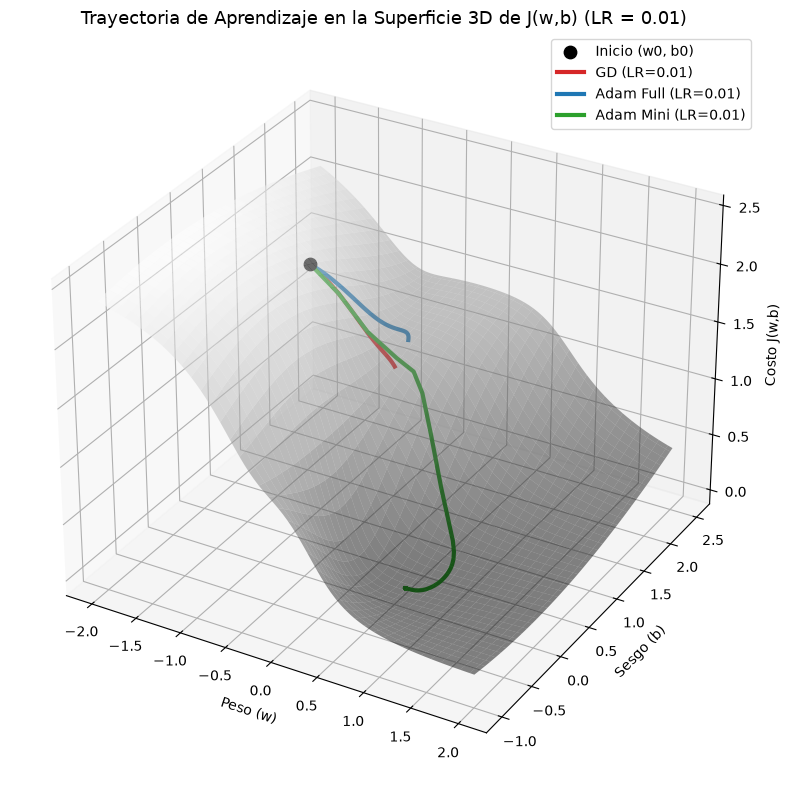

In [81]:
# Learning rate elegido: en el caso de 0.01 se observa una marcada diferencia
# entre los tres: GD y Adam full-batch se separan del rendimiento superior
# de Adam mini-batch
lr_elegido = 0.01

# Grilla para la superficie de costo J(w, b)
w_range = np.linspace(-2.0, 2.0, 80)
b_range = np.linspace(-1.0, 2.5, 80)
W, B = np.meshgrid(w_range, b_range)

# Se calcula J(w, b) para cada combinación de la grilla
J_grid = np.zeros(W.shape)
for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        y_hat_grid = np.tanh(W[i, j] * x + B[i, j])
        J_grid[i, j] = np.mean((y_hat_grid - y) ** 2)

# Trayectorias (w, b, J) para el LR elegido
def obtener_trayectoria(opt_name):
    # Se entrena guardando la trayectoria completa de (w, b, costo)
    w, b = w_init, b_init
    trayectoria = []

    # Parámetros de Adam
    mw, mb, vw, vb = 0.0, 0.0, 0.0, 0.0
    t = 0

    for epoch in range(100):
        if opt_name == 'GD':
            y_hat = forward_pass(x, w, b)
            costo = calcular_costo(y_hat, y)
            trayectoria.append((w, b, costo))
            dw, db = calcular_gradientes(x, y, y_hat)
            w -= lr_elegido * dw
            b -= lr_elegido * db

        elif opt_name == 'Adam Full':
            y_hat = forward_pass(x, w, b)
            costo = calcular_costo(y_hat, y)
            trayectoria.append((w, b, costo))
            dw, db = calcular_gradientes(x, y, y_hat)
            t += 1
            mw = 0.9 * mw + 0.1 * dw
            mb = 0.9 * mb + 0.1 * db
            vw = 0.999 * vw + 0.001 * (dw**2)
            vb = 0.999 * vb + 0.001 * (db**2)
            mw_h, mb_h = mw / (1 - 0.9**t), mb / (1 - 0.9**t)
            vw_h, vb_h = vw / (1 - 0.999**t), vb / (1 - 0.999**t)
            w -= lr_elegido * mw_h / (np.sqrt(vw_h) + 1e-8)
            b -= lr_elegido * mb_h / (np.sqrt(vb_h) + 1e-8)

        elif opt_name == 'Adam Mini':
            y_hat_full = forward_pass(x, w, b)
            costo_full = calcular_costo(y_hat_full, y)
            trayectoria.append((w, b, costo_full))

            indices = np.arange(len(x))
            np.random.shuffle(indices)
            xs, ys = x[indices], y[indices]

            for i in range(0, len(x), 32):
                xb, yb = xs[i:i+32], ys[i:i+32]
                t += 1
                yh_b = forward_pass(xb, w, b)
                dw, db = calcular_gradientes(xb, yb, yh_b)
                mw = 0.9 * mw + 0.1 * dw
                mb = 0.9 * mb + 0.1 * db
                vw = 0.999 * vw + 0.001 * (dw**2)
                vb = 0.999 * vb + 0.001 * (db**2)
                mw_h, mb_h = mw / (1 - 0.9**t), mb / (1 - 0.9**t)
                vw_h, vb_h = vb / (1 - 0.999**t), vb / (1 - 0.999**t)
                w -= lr_elegido * mw_h / (np.sqrt(vw_h) + 1e-8)
                b -= lr_elegido * mb_h / (np.sqrt(vb_h) + 1e-8)

    return np.array(trayectoria)

tray_gd = obtener_trayectoria('GD')
tray_af = obtener_trayectoria('Adam Full')
tray_am = obtener_trayectoria('Adam Mini')

# Graficación
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Superficie translúcida
surf = ax.plot_surface(W, B, J_grid, cmap='gray', alpha=0.5, edgecolor='none')

# Punto de inicio común
ax.scatter([w_init], [b_init], [tray_gd[0, 2]], color='black', s=80, marker='o', label='Inicio (w0, b0)', zorder=5)

# Trayectorias
ax.plot(tray_gd[:, 0], tray_gd[:, 1], tray_gd[:, 2], color='#d62728', linewidth=3, label='GD (LR=0.01)')
ax.plot(tray_af[:, 0], tray_af[:, 1], tray_af[:, 2], color='#1f77b4', linewidth=3, label='Adam Full (LR=0.01)')
ax.plot(tray_am[:, 0], tray_am[:, 1], tray_am[:, 2], color='#2ca02c', linewidth=3, label='Adam Mini (LR=0.01)')

ax.set_title(f"Trayectoria de Aprendizaje en la Superficie 3D de J(w,b) (LR = {lr_elegido})", fontsize=13)
ax.set_xlabel("Peso (w)", fontsize=10)
ax.set_ylabel("Sesgo (b)", fontsize=10)
ax.set_zlabel("Costo J(w,b)", fontsize=10)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

# **PREGUNTA 2** (Temas de la clase 3)

# Caso: Predicción del gasto promedio de los usuarios usando redes neuronales

**Descarga del dataset:**  
El conjunto de datos puede descargarse en el siguiente [enlace](https://drive.google.com/file/d/1e_FRepCpHBWWGj3TYG4HY7WHALCyR4wQ/view?usp=sharing)

---

## Descripción general:

El dataset recopila información sobre las compras realizadas por distintos clientes en una tienda durante el último año.  
Cada registro representa una transacción e incluye datos tanto del cliente como del producto adquirido.

---

## El dataset contiene la siguiente información:

- **User_ID:** Código identificador único del cliente que efectuó la compra.  
- **Product_ID:** Código identificador único del producto adquirido.  
- **Age:** Rango de edad del cliente.  
- **Gender:** Género del cliente (F: Femenino, M: Masculino).  
- **Marital_Status:** Estado civil del cliente (0: Soltero, 1: Casado).  
- **City_Category:** Tipo de zona donde se encuentra la sucursal donde se realizó la compra.  
  - A: Barrio de clase alta  
  - B: Barrio de clase media  
  - C: Barrio de clase media-baja  
- **Stay_In_Current_City_Years:** Número de años que el cliente ha venido comprando en la tienda desde su primera visita.  
- **Product_Category:** Categoría del producto comprado.  
- **Product_Subcategory_1:** Subcategoría principal del producto.  
- **Product_Subcategory_2:** Subcategoría secundaria del producto.  
- **Purchase:** Monto pagado por el producto en esa transacción.

---

## Objetivo del caso de estudio:

Desarrollar un **modelo predictivo** capaz de estimar el **gasto promedio** que realizará un cliente, a partir de su información demográfica y sus patrones de compra. Tener en cuenta que se busca que el modelo prediga el gasto promedio por cliente, no el gasto en cada nueva transacción individual. Y la idea sería que una vez que el modelo ya esté listo y entrenado, se use para estimar apartir de datos de clientes relativamente nuevos, que solo llevan entre 3 a 5 visitas y compras en la tienda.


### 2a) EDA y preparación del dataset (2 puntos)
Realizar el análisis exploratorio del dataset (EDA) con las herramientas vistas en materias anteriores.
- Analizar qué columnas sirven para lograr el objetivo y cuáles no (drop) en base al contexto del negocio y a lo entendido del caso de estudio (feature engineering).
- Analizar con qué columnas vale la pena hacer un tratamiento de valores nulos o si simplemente se debe dropear toda la columna porque ya no tiene salvación.
- Analizar a qué variables se les debe hacer label encoding, a cuáles one-hot encoding, ordinal encoding o mapping encoding. Explicar detalladamente los criterios utilizados para tomar esas decisiones.
- Transformar, agrupar, combinar y operar la data de tal manera que sea útil para extraer patrones de gastos y tendencias de gustos de cada cliente. **Tener mucho cuidado con el data leakage, ocurre mucho cuando se usan proporciones como nuevas columnas**.



Redactar las conclusiones preliminares que puedan notar de cada feature y justificar el porqué de cada encoding, limpieza o transformación aplicada. Cada justificación se debe redactar a detalle y sustentar con gráficas y/o tablas.


In [82]:
import pandas as pd
import seaborn as sns

In [83]:
# from google.colab import drive
# drive.mount('/content/drive')

In [84]:
# df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/AP/TP1/dataset_compras.csv')
# df.head()

In [85]:
df = pd.read_csv('./dataset_compras.csv')
df.head()

,User_ID,Product_ID,Age,Gender,Marital_Status,City_Category,Stay_In_Current_City_Years,Product_Category,Product_Subcategory_1,Product_Subcategory_2,Purchase
0,1044096,P00017122,46-50,F,1,B,1,10,45.0,NaN,1810
1,1071818,P00074517,36-45,M,0,A,3,11,27.0,NaN,12351
2,1022986,P00013694,36-45,M,1,A,5+,4,28.0,NaN,127
3,1094684,P00049122,36-45,M,1,A,1,16,9.0,8.0,2214
4,1004157,P00006469,46-50,M,1,A,5+,3,NaN,NaN,7142


Tratamiento de valores nulos



In [86]:
nulos_columna = df.isnull().sum()

# 2. Porcentaje de valores nulos por feature
porcentaje_nulos = (df.isnull().sum() / len(df)) * 100

# Consolidado en un DataFrame
resumen_nulos = pd.DataFrame(
    {"Total nulos": nulos_columna, "Porcentaje (%)": porcentaje_nulos}
)

print(resumen_nulos)

                            Total nulos  Porcentaje (%)
User_ID                               0        0.000000
Product_ID                            0        0.000000
Age                                   0        0.000000
Gender                                0        0.000000
Marital_Status                        0        0.000000
City_Category                         0        0.000000
Stay_In_Current_City_Years            0        0.000000
Product_Category                      0        0.000000
Product_Subcategory_1             41818       22.886258
Product_Subcategory_2            105260       57.606953
Purchase                              0        0.000000


Se decide en función a los resultados:
- **Eliminar la columna Product_Subcategory_2**: debido al alto porcentaje de nulos no tiene sentido buscar una imputación
- **Imputación de Product_Subcategory_1**: se decide imputar el valor "-1" indicando que no tiene categoría. Es decir, se agrega una categoría nueva ("sin subcategoría")

In [87]:
# Eliminación de Product_Subcategory_2
df = df.drop(columns=["Product_Subcategory_2"])

# Imputación de Product_Subcategory_1
df["Product_Subcategory_1"] = df["Product_Subcategory_1"].fillna(-1)

Debido a que solo interesa el gasto por usuario (y es lo que va a buscar predecir) se elimina la columna Product_ID y se agrupa por promedio. Nota: ya que todas las columnas tienen nombre en inglés se elige continuar con esa convención y se llama "Avg_Purchase".


In [88]:
df = df.drop(columns=["Product_ID"])

df_cliente = (
    df.groupby("User_ID")["Purchase"].mean().reset_index(name="Avg_Purchase")
)

Dado que las variables demográficas no cambian por cliente, se las agrupa y asigna

In [89]:
# Columnas demográficas
col_demograficas = [
    "Gender",
    "Age",
    "Marital_Status",
    "City_Category",
    "Stay_In_Current_City_Years",
]

df_demografia = df.groupby("User_ID")[col_demograficas].first().reset_index()

# Se une a df_cliente
df_cliente = df_cliente.merge(df_demografia, on="User_ID")
df_cliente.head()

,User_ID,Avg_Purchase,Gender,Age,Marital_Status,City_Category,Stay_In_Current_City_Years
0,1000035,1912.923077,M,18-25,0,A,1
1,1000044,14338.906977,M,36-45,1,A,4
2,1000070,4120.809524,M,46-50,1,B,4
3,1000087,11228.219512,F,55+,1,C,4
4,1000115,4673.882353,F,46-50,1,C,2


Encoding:
- Gender: se mapea como 0 o 1 (label encoding)
- Age: categórica ordinal, se mapea a una escala numérica para preservar relación de orden
- Stay_In_Current_City_Years: categórica ordinal, mismo criterio que con Age
- City_Category: nominal, se utiliza one-hot encoding
- Marital_Status: ya viene codificada como 0 o 1

In [90]:
# Gender
gender_map = {"F": 0, "M": 1}
df_cliente["Gender_Encoded"] = df_cliente["Gender"].map(gender_map)

# Age
age_map = {
    "0-17": 0,
    "18-25": 1,
    "26-35": 2,
    "36-45": 3,
    "46-50": 4,
    "51-55": 5,
    "55+": 6,
}
df_cliente["Age_Encoded"] = df_cliente["Age"].map(age_map)


# Stay_In_Current_City_Years
stay_map = {'1': 1, '2': 2, '3': 3, '4': 4, '5+': 5}
df_cliente["Stay_Encoded"] = df_cliente["Stay_In_Current_City_Years"].map(
    stay_map
)

# City_Category
df_cliente = pd.get_dummies(
    df_cliente, columns=["City_Category"], drop_first=True, dtype=int
)

# 4. Se eliminan las originales (ya fueron codificadas)
df_cliente = df_cliente.drop(
    columns=["Gender", "Age", "Stay_In_Current_City_Years"]
)
df_cliente.head()

,User_ID,Avg_Purchase,Marital_Status,Gender_Encoded,Age_Encoded,Stay_Encoded,City_Category_B,City_Category_C
0,1000035,1912.923077,0,1,1,1,0,0
1,1000044,14338.906977,1,1,3,4,0,0
2,1000070,4120.809524,1,1,4,4,1,0
3,1000087,11228.219512,1,0,6,4,0,1
4,1000115,4673.882353,1,0,4,2,0,1


Feature engineering: para capturar la diversidad y los hábitos de consumo de cada cliente (sin data leakage), se transforma la variable Product_Category mediante una matriz de frecuencias por usuario (frecuencia absoluta de compras en cada una de las 20 categorías de producto).

In [91]:
# Matriz de frecuencias por categoría de producto para cada cliente
cat_counts = (
    pd.crosstab(df["User_ID"], df["Product_Category"])
    .add_prefix("cat_count_")
    .reset_index()
)

# Se unen las frecuencias con df_cliente actual
df_cliente = df_cliente.merge(cat_counts, on="User_ID")
df_cliente.head()

,User_ID,Avg_Purchase,Marital_Status,Gender_Encoded,Age_Encoded,Stay_Encoded,City_Category_B,City_Category_C,cat_count_1,cat_count_2,...,cat_count_11,cat_count_12,cat_count_13,cat_count_14,cat_count_15,cat_count_16,cat_count_17,cat_count_18,cat_count_19,cat_count_20
0,1000035,1912.923077,0,1,1,1,0,0,0,0,...,0,0,0,0,1,5,0,0,0,0
1,1000044,14338.906977,1,1,3,4,0,0,1,0,...,1,1,4,0,1,2,2,6,3,5
2,1000070,4120.809524,1,1,4,4,1,0,2,1,...,3,2,0,4,3,6,5,0,0,0
3,1000087,11228.219512,1,0,6,4,0,1,2,1,...,1,1,3,1,0,0,2,1,5,8
4,1000115,4673.882353,1,0,4,2,0,1,0,0,...,0,0,0,0,3,1,0,0,0,1


Escalado de datos

In [92]:
from sklearn.preprocessing import StandardScaler

In [93]:
user_ids = df_cliente["User_ID"]
y = df_cliente["Avg_Purchase"]

# Matriz de entrada X (todas las columnas excepto User_ID y Avg_Purchase)
X = df_cliente.drop(columns=["User_ID", "Avg_Purchase"])

# Se inicializa y aplica StandardScaler a las features X
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

# Se convierte el resultado a DataFrame par amantener los nombres de columnas
df_X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
df_X_scaled.head()

,Marital_Status,Gender_Encoded,Age_Encoded,Stay_Encoded,City_Category_B,City_Category_C,cat_count_1,cat_count_2,cat_count_3,cat_count_4,...,cat_count_11,cat_count_12,cat_count_13,cat_count_14,cat_count_15,cat_count_16,cat_count_17,cat_count_18,cat_count_19,cat_count_20
0,-1.208014,0.951395,-1.347983,-1.140671,-0.714971,-0.614053,-0.763573,-0.623846,-0.974020,-0.959109,...,-0.906176,-0.921844,-0.666811,-0.746695,0.142427,2.491073,-1.242675,-0.656628,-0.662891,-0.676888
1,0.827805,0.951395,-0.209744,0.963615,-0.714971,-0.614053,0.142812,-0.623846,0.840245,-0.041013,...,-0.314790,-0.364568,1.959095,-0.746695,0.142427,0.302439,0.104500,3.110786,1.276463,2.147089
2,0.827805,0.951395,0.359375,0.963615,1.398658,-0.614053,1.049197,0.526061,-0.611167,-0.041013,...,0.867981,0.192707,-0.666811,2.908459,2.205819,3.220618,2.125264,-0.656628,-0.662891,-0.676888
3,0.827805,-1.051088,1.497614,0.963615,-0.714971,1.628523,1.049197,0.526061,-0.611167,0.877083,...,-0.314790,-0.364568,1.302618,0.167093,-0.889269,-1.156650,0.104500,-0.028725,2.569365,3.841474
4,0.827805,-1.051088,0.359375,-0.439242,-0.714971,1.628523,-0.763573,-0.623846,0.114539,1.795180,...,-0.906176,-0.921844,-0.666811,-0.746695,2.205819,-0.427106,-1.242675,-0.656628,-0.662891,-0.112093


In [94]:
# Verificación de escalado
df_verificacion = pd.DataFrame(
    {
        "Media": df_X_scaled.mean().round(4),
        "Desv_Estandar": df_X_scaled.std().round(4),
    }
)

with pd.option_context("display.max_rows", None):
    display(df_verificacion)

,Media,Desv_Estandar
Marital_Status,-0.0,1.0001
Gender_Encoded,0.0,1.0001
Age_Encoded,0.0,1.0001
Stay_Encoded,-0.0,1.0001
City_Category_B,-0.0,1.0001
City_Category_C,-0.0,1.0001
cat_count_1,0.0,1.0001
cat_count_2,0.0,1.0001
cat_count_3,0.0,1.0001
cat_count_4,0.0,1.0001


Separación del dataset train/test

In [95]:
from sklearn.model_selection import train_test_split

In [96]:
# Train (80%)
# Test (20%)
# Se incluyen user_ids para no perder la correspondencia con los clientes
X_train, X_test, y_train, y_test, user_ids_train, user_ids_test = (
    train_test_split(
        df_X_scaled,
        y,
        user_ids,
        test_size=0.20,
        random_state=42,
    )
)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

# Se verifican las dimensiones obtenidas
print(f"Dataset completo: {df_X_scaled.shape[0]} usuarios")
print(f"Muestra de Entrenamientos (Train): {X_train.shape[0]} usuarios")
print(f"Muestra de Prueba (Test): {X_test.shape[0]} usuarios")

Dataset completo: 7432 usuarios
Muestra de Entrenamientos (Train): 5945 usuarios
Muestra de Prueba (Test): 1487 usuarios


### 2b) Modelo Multilayer Perceptron (MLP) (2.5 puntos)
Entrenar un modelo de deep learning usando PyTorch que consuma el dataframe ya pre-procesado en el paso anterior.

Características para el diseño de la red:
- El modelo debe tener un mínimo de 3 capas ocultas.
- El modelo debe tener un mínimo de 32 neuronas por cada capa oculta.
- Cada capa oculta debe tener su respectiva función de activación.
- La elección de la función de activación de las capas ocultas es libre, pero se debe justificar por qué se está eligiendo esa, ya sea mediante conceptos teóricos o con resultados de pruebas empíricas.
- Analizar y justificar cuál es la mejor función de costo, algoritmo de optimización y learning rate para este modelo.
- Analizar cuál sería el mejor número de épocas para entrenar el modelo.
- Opcional: Incluir técnicas de regularización como dropout en las capas ocultas.

In [97]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import r2_score

Entrenando en: cpu

Iniciando Entrenamiento...
Época 001/120 | Train Loss (MSE Scaled): 0.2492 | Val Loss: 0.0942 | Train R2: 0.7508 | Val R2: 0.9007


Época 010/120 | Train Loss (MSE Scaled): 0.0860 | Val Loss: 0.0686 | Train R2: 0.9140 | Val R2: 0.9277
Época 020/120 | Train Loss (MSE Scaled): 0.0770 | Val Loss: 0.0636 | Train R2: 0.9230 | Val R2: 0.9330
Época 030/120 | Train Loss (MSE Scaled): 0.0709 | Val Loss: 0.0639 | Train R2: 0.9291 | Val R2: 0.9327
Época 040/120 | Train Loss (MSE Scaled): 0.0646 | Val Loss: 0.0645 | Train R2: 0.9354 | Val R2: 0.9320

¡Early Stopping activado en la época 47! La mejor época fue la 32 con Val Loss: 0.0621


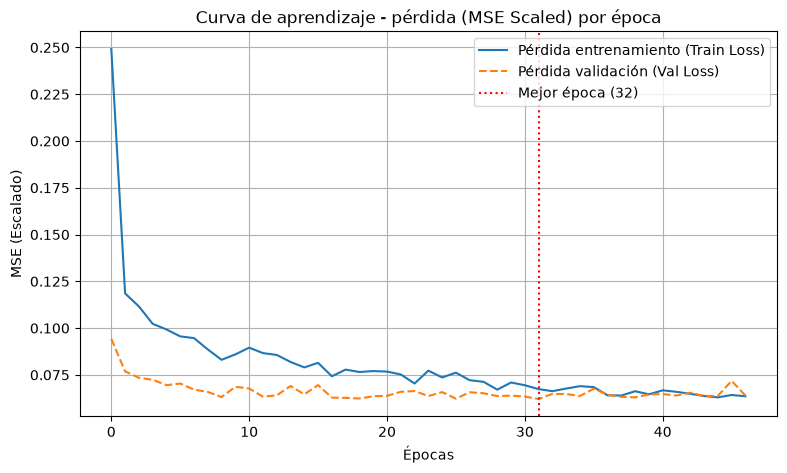

In [98]:
# Fijar semillas para reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

# Configurar dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Entrenando en: {device}")

# Convertir a Tensores de PyTorch
X_tr_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_tr_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)

X_te_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_te_tensor = torch.tensor(y_test_scaled, dtype=torch.float32)

# Crear DataLoaders para procesamiento por lotes (batches)
train_dataset = TensorDataset(X_tr_tensor, y_tr_tensor)
test_dataset = TensorDataset(X_te_tensor, y_te_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Arquitectura del modelo (MLP)
class MLPRegressor(nn.Module):

    def __init__(self, input_dim):
        super(MLPRegressor, self).__init__()

        self.network = nn.Sequential(
            # Capa Oculta 1: 128 neuronas
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.01),
            nn.Dropout(0.1),
            # Capa Oculta 2: 64 neuronas
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.01),
            nn.Dropout(0.1),
            # Capa Oculta 3: 32 neuronas
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.01),
            # Capa de Salida: 1 neurona (sin activación para regresión)
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.network(x)


# Se instancia el modelo
input_features = X_train.shape[1]
model = MLPRegressor(input_dim=input_features).to(device)

# Se define función de costo y optimizador
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

# Bucle de entrenamiento con early stopping
epochs = 120
patience = 15
best_val_loss = float("inf")
patience_counter = 0

history_train_loss = []
history_val_loss = []
history_train_r2 = []
history_val_r2 = []

print("\nIniciando Entrenamiento...")
for epoch in range(1, epochs + 1):
    # Modo Entrenamiento
    model.train()
    running_train_loss = 0.0
    train_preds, train_targets = [], []

    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        optimizer.zero_grad()
        predictions = model(batch_x)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * batch_x.size(0)
        train_preds.append(predictions.detach().cpu())
        train_targets.append(batch_y.cpu())

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    epoch_train_r2 = r2_score(
        torch.cat(train_targets).numpy(), torch.cat(train_preds).numpy()
    )

    # Modo evaluación (Validación/Test)
    model.eval()
    running_val_loss = 0.0
    val_preds, val_targets = [], []

    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            predictions = model(batch_x)
            loss = criterion(predictions, batch_y)
            running_val_loss += loss.item() * batch_x.size(0)
            val_preds.append(predictions.cpu())
            val_targets.append(batch_y.cpu())

    epoch_val_loss = running_val_loss / len(test_loader.dataset)
    epoch_val_r2 = r2_score(
        torch.cat(val_targets).numpy(), torch.cat(val_preds).numpy()
    )

    history_train_loss.append(epoch_train_loss)
    history_val_loss.append(epoch_val_loss)
    history_train_r2.append(epoch_train_r2)
    history_val_r2.append(epoch_val_r2)

    # Chequeo de early stopping
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_epoch = epoch
        torch.save(model.state_dict(), "best_mlp_model.pth")
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 10 == 0 or epoch == 1:
        print(
            f"Época {epoch:03d}/{epochs} | Train Loss (MSE Scaled): {epoch_train_loss:.4f} | "
            f"Val Loss: {epoch_val_loss:.4f} | Train R2: {epoch_train_r2:.4f} | Val R2: {epoch_val_r2:.4f}"
        )

    if patience_counter >= patience:
        print(
            f"\n¡Early Stopping activado en la época {epoch}! La mejor época fue la {best_epoch} con Val Loss: {best_val_loss:.4f}"
        )
        break

# Cargar el mejor modelo guardado
model.load_state_dict(torch.load("best_mlp_model.pth"))

# Gráfico de pérdida
plt.figure(figsize=(9, 5))
plt.plot(history_train_loss, label="Pérdida entrenamiento (Train Loss)")
plt.plot(history_val_loss, label="Pérdida validación (Val Loss)", linestyle="--")
plt.axvline(
    best_epoch - 1,
    color="red",
    linestyle=":",
    label=f"Mejor época ({best_epoch})",
)
plt.title("Curva de aprendizaje - pérdida (MSE Scaled) por época")
plt.xlabel("Épocas")
plt.ylabel("MSE (Escalado)")
plt.legend()
plt.grid(True)
plt.show()

#### Justificación del diseño

- Capas: supera el mínimo pedido (3x32) y aprovecha las ~25 features (demográficas + conteos por categoría).
- Activación: LeakyReLU se prefiere a ReLU porque puede ser que una neurona reciba pre-activaciones negativas, y ReLU las mataría (gradiente 0 permanente).
- Costo: MSE es estándar para regresión.
- Optimización: AdamW desacopla el weight decay del GD, lr=0.001 es el valor típico de la familia Adam.
- Regularización: porque el dataset de clientes es moderado (~7400 filas) en relación a los parámetros del modelo.
- Épocas: se usa early stopping sobre la pérdida de validación.

### 2c) Evaluación del Modelo (1 punto)
- Graficar las evoluciones por época de la función de costo y del $R^2$, tanto para el set de train como el de validation.
- Gráfica scatter de Real VS Predicho en el set de validation.
- Explicar el proceso estratégico de iteracion utilizado para conseguir los mejores resultados y justificar los resultados obtenidos.
- Un resultado aceptable sería un $R^2$ de por lo menos 0.70 para el set de validation.

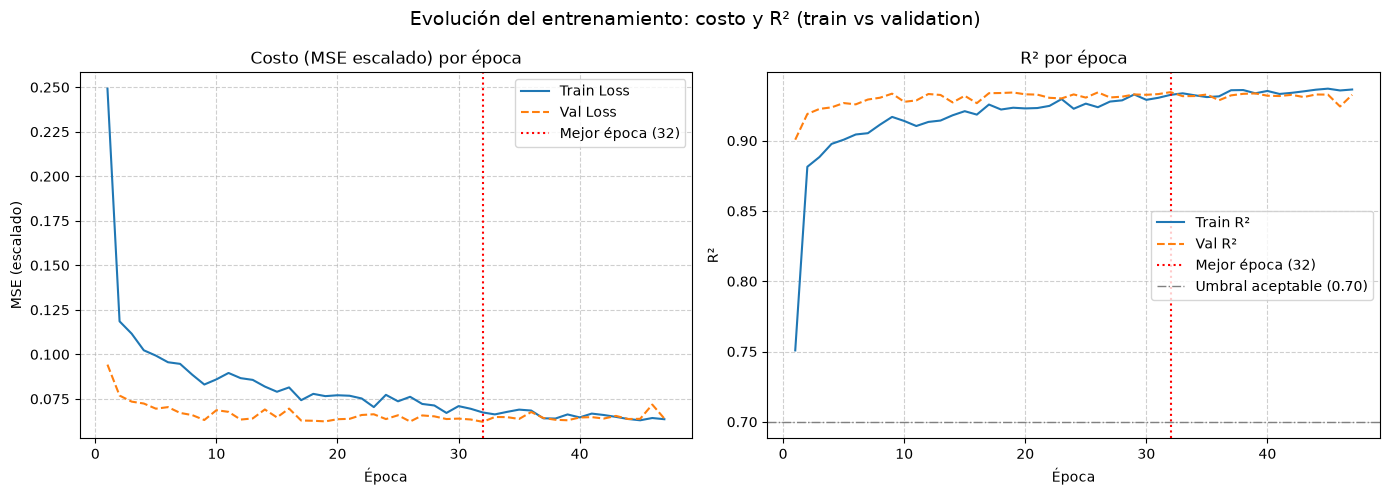

Mejor época: 32
Train R² en la mejor época: 0.9326
Val R²   en la mejor época: 0.9346


In [99]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history_train_loss) + 1)

# Evolución de la función de costo
ax1.plot(epochs_range, history_train_loss, label="Train Loss")
ax1.plot(epochs_range, history_val_loss, label="Val Loss", linestyle="--")
ax1.axvline(best_epoch, color="red", linestyle=":", label=f"Mejor época ({best_epoch})")
ax1.set_title("Costo (MSE escalado) por época")
ax1.set_xlabel("Época")
ax1.set_ylabel("MSE (escalado)")
ax1.legend()
ax1.grid(True, linestyle="--", alpha=0.6)

# Evolución del R2
ax2.plot(epochs_range, history_train_r2, label="Train R²")
ax2.plot(epochs_range, history_val_r2, label="Val R²", linestyle="--")
ax2.axvline(best_epoch, color="red", linestyle=":", label=f"Mejor época ({best_epoch})")
ax2.axhline(0.70, color="gray", linestyle="-.", linewidth=1, label="Umbral aceptable (0.70)")
ax2.set_title("R² por época")
ax2.set_xlabel("Época")
ax2.set_ylabel("R²")
ax2.legend()
ax2.grid(True, linestyle="--", alpha=0.6)

plt.suptitle("Evolución del entrenamiento: costo y R² (train vs validation)", fontsize=14)
plt.tight_layout()
plt.show()

print(f"Mejor época: {best_epoch}")
print(f"Train R² en la mejor época: {history_train_r2[best_epoch - 1]:.4f}")
print(f"Val R²   en la mejor época: {history_val_r2[best_epoch - 1]:.4f}")

R² en validation (escala original de Avg_Purchase): 0.9346


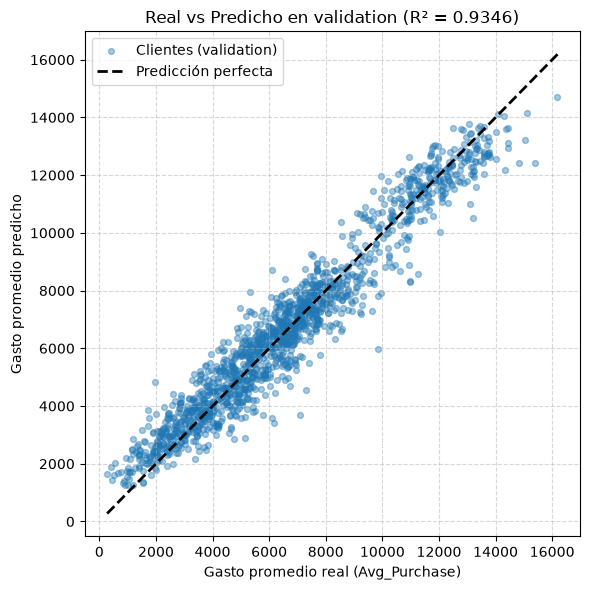

In [100]:
# Predicciones del mejor modelo sobre el set de validation, vueltas a la escala original
model.eval()
with torch.no_grad():
    val_preds_scaled = model(X_te_tensor.to(device)).cpu().numpy()

val_preds = scaler_y.inverse_transform(val_preds_scaled).ravel()
val_real = scaler_y.inverse_transform(y_test_scaled).ravel()

r2_final = r2_score(val_real, val_preds)
print(f"R² en validation (escala original de Avg_Purchase): {r2_final:.4f}")

plt.figure(figsize=(6, 6))
plt.scatter(val_real, val_preds, alpha=0.4, s=18, color="#1f77b4", label="Clientes (validation)")

lim_min = min(val_real.min(), val_preds.min())
lim_max = max(val_real.max(), val_preds.max())
plt.plot([lim_min, lim_max], [lim_min, lim_max], color="black", linewidth=2, linestyle="--", label="Predicción perfecta")

plt.xlabel("Gasto promedio real (Avg_Purchase)")
plt.ylabel("Gasto promedio predicho")
plt.title(f"Real vs Predicho en validation (R² = {r2_final:.4f})")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

#### Iteración y justificación de resultados

Se arrancó con una red mínima (3x32, sin regularización) donde el train loss bajaba mucho más rápido que el val loss (overfitting), por lo que se agregó Dropout y BatchNorm. Ampliar la red a 128-64-32 mejoró el R² de validation. Dejar que el early stopping elija la cantidad de épocas terminó de estabilizar el entrenamiento.

Con esta configuración el modelo converge con $R^2 >> 0.70$. El scatter de Real vs Predicho muestra los puntos bien agrupados sobre la diagonal.

### 2d) Conclusiones finales (0.5 puntos)
Redactar de manera detallada las conclusiones finales y si se cumplió con el objetivo o no.

A partir de datos demográficos y de patrones de compra por categoría, el modelo estima razonablemente bien el gasto promedio de un cliente, $R^2$ de validation 0.9346.

Una limitación: el modelo se entrenó con el historial completo de cada cliente, pero el objetivo final es aplicarlo a clientes nuevos con pocas visitas. Como los `cat_count_*` son conteos absolutos, un cliente nuevo va a tener conteos bajos simplemente por tener poco historial (no porque gaste poco), lo que podría hacer que el modelo le subestime el gasto. Convendría entrenar usando solo las primeras compras de cada cliente o normalizar los conteos por cantidad de visitas.